<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/R_service_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — INSTALL SIONNA
# ============================================================

!pip -q install "sionna==2.1.0" openpyxl

print("Sionna installation completed.")
print("If Colab requests a runtime restart:")
print("Runtime -> Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 673.2/673.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take i

In [1]:
# ============================================================
# CELL 2 — IMPORTS AND ENVIRONMENT CHECK
# ============================================================

import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import sionna.phy

from sionna.phy.nr import (
    PUSCHConfig,
    PUSCHTransmitter,
    PUSCHReceiver
)

from sionna.phy.channel import (
    RayleighBlockFading,
    OFDMChannel
)

from sionna.phy.utils import compute_ber

warnings.filterwarnings("ignore")

print("================================================")
print("ENVIRONMENT")
print("================================================")

print("Python      :", __import__("sys").version)
print("PyTorch     :", torch.__version__)
print("NumPy       :", np.__version__)

print("Sionna      :", getattr(__import__("sionna"), "__version__", "2.x"))

print("CUDA avail. :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    DEVICE = "cuda"
else:
    print("GPU         : CPU")
    DEVICE = "cpu"

print("================================================")

ENVIRONMENT
Python      : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch     : 2.11.0+cpu
NumPy       : 2.5.3
Sionna      : 2.1.0
CUDA avail. : False
GPU         : CPU


In [2]:
# ============================================================
# CELL 3 — EXPERIMENT CONFIGURATION
# ============================================================

SEED = 42

# Sionna's own random generator
sionna.phy.config.seed = SEED

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

OUTPUT_DIR = Path("/content/Rservice_S0_S7_Sionna")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Service configuration
# ------------------------------------------------------------

SERVICE_DURATION = 60          # seconds / service slots
DT = 1.0

Q0 = 10.0                      # reference service rate [Mbps]

RECOVERY_THRESHOLD = 0.90


# ------------------------------------------------------------
# Rservice thresholds
#
# These are experimental values.
# They are NOT numerical values specified by the paper.
# ------------------------------------------------------------

T_NMIN_MS = 220.0
D_MIN_MS = 160.0
E_TH_MBPS = 1.0
T_PROC_MS = 80.0
T_SLEEP_MAX_S = 4.0

C_MS = 5.0


# ------------------------------------------------------------
# LLM / xApp
# ------------------------------------------------------------

N_ITERATIONS = 10


# ------------------------------------------------------------
# RIS
# ------------------------------------------------------------

N_RIS_ITERATIONS = 10


# ------------------------------------------------------------
# Sionna simulation
# ------------------------------------------------------------

SIONNA_BATCH_SIZE = 16

# Number of PUSCH transmissions per service second
# This is a simulation abstraction.
PHY_SAMPLES_PER_SLOT = 1


print("Configuration loaded.")
print()
print("Q0                 =", Q0, "Mbps")
print("Service duration   =", SERVICE_DURATION, "s")
print("Sionna batch       =", SIONNA_BATCH_SIZE)
print("T_nmin             =", T_NMIN_MS, "ms")
print("d_min              =", D_MIN_MS, "ms")
print("e_th               =", E_TH_MBPS, "Mbps")
print("T_proc             =", T_PROC_MS, "ms")
print("T_sleep,max        =", T_SLEEP_MAX_S, "s")

Configuration loaded.

Q0                 = 10.0 Mbps
Service duration   = 60 s
Sionna batch       = 16
T_nmin             = 220.0 ms
d_min              = 160.0 ms
e_th               = 1.0 Mbps
T_proc             = 80.0 ms
T_sleep,max        = 4.0 s


In [3]:
# ============================================================
# CELL 4 — S0–S7 DEFINITIONS
# ============================================================

SCENARIOS = {

    # --------------------------------------------------------
    # S0
    # --------------------------------------------------------
    "S0": {
        "description": "Normal operation",

        # Sionna PHY
        "noise_variance": 0.010,

        # Service/control
        "service_factor": 1.00,

        # LLM
        "llm_delay_factor": 1.00,

        # QoS
        "qos_mismatch": 0.00,

        # RIS
        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S1
    # --------------------------------------------------------
    "S1": {
        "description": "Mild QoS degradation",

        "noise_variance": 0.025,
        "service_factor": 0.95,

        "llm_delay_factor": 1.00,
        "qos_mismatch": 0.00,

        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S2
    # --------------------------------------------------------
    "S2": {
        "description": "Moderate QoS degradation",

        "noise_variance": 0.060,
        "service_factor": 0.85,

        "llm_delay_factor": 1.00,
        "qos_mismatch": 0.00,

        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S3
    # --------------------------------------------------------
    "S3": {
        "description": "Severe QoS degradation",

        "noise_variance": 0.120,
        "service_factor": 0.70,

        "llm_delay_factor": 1.00,
        "qos_mismatch": 0.00,

        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S4
    # --------------------------------------------------------
    "S4": {
        "description": "Delayed AI/resource adjustment",

        # PHY can be moderate
        "noise_variance": 0.060,
        "service_factor": 0.85,

        # AI/control delay
        "llm_delay_factor": 2.20,

        "qos_mismatch": 0.00,

        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S5
    # --------------------------------------------------------
    "S5": {
        "description": "QoS allocation mismatch",

        "noise_variance": 0.060,
        "service_factor": 0.85,

        "llm_delay_factor": 1.00,

        # deliberate allocation mismatch
        "qos_mismatch": 1.00,

        "ris_delay_factor": 1.00,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S6
    # --------------------------------------------------------
    "S6": {
        "description": "RIS reconfiguration delay",

        "noise_variance": 0.040,
        "service_factor": 0.90,

        "llm_delay_factor": 1.00,
        "qos_mismatch": 0.00,

        # RIS delay
        "ris_delay_factor": 1.80,
        "ris_sleep_max": 2.0
    },


    # --------------------------------------------------------
    # S7
    # --------------------------------------------------------
    "S7": {
        "description": "RIS sleep-duration variation",

        "noise_variance": 0.040,
        "service_factor": 0.90,

        "llm_delay_factor": 1.00,
        "qos_mismatch": 0.00,

        "ris_delay_factor": 1.00,

        # Excessive RIS sleep
        "ris_sleep_max": 5.5
    }
}

scenario_order = list(SCENARIOS.keys())

display(
    pd.DataFrame(SCENARIOS).T
)

,description,noise_variance,service_factor,llm_delay_factor,qos_mismatch,ris_delay_factor,ris_sleep_max
S0,Normal operation,0.01,1.0,1.0,0.0,1.0,2.0
S1,Mild QoS degradation,0.025,0.95,1.0,0.0,1.0,2.0
S2,Moderate QoS degradation,0.06,0.85,1.0,0.0,1.0,2.0
S3,Severe QoS degradation,0.12,0.7,1.0,0.0,1.0,2.0
S4,Delayed AI/resource adjustment,0.06,0.85,2.2,0.0,1.0,2.0
S5,QoS allocation mismatch,0.06,0.85,1.0,1.0,1.0,2.0
S6,RIS reconfiguration delay,0.04,0.9,1.0,0.0,1.8,2.0
S7,RIS sleep-duration variation,0.04,0.9,1.0,0.0,1.0,5.5


In [4]:
# ============================================================
# CELL 5 — SIONNA 5G NR PUSCH CONFIGURATION
# ============================================================

pusch_config = PUSCHConfig()

# Instantiate transmitter
pusch_transmitter = PUSCHTransmitter(
    pusch_config,
    return_bits=True,
    output_domain="freq",
    device=DEVICE
)

# Instantiate receiver
pusch_receiver = PUSCHReceiver(
    pusch_transmitter,
    device=DEVICE
)

print("PUSCH configuration created.")

print()
print("Resource grid:")
print("  OFDM symbols :", pusch_transmitter.resource_grid.num_ofdm_symbols)
print("  FFT size     :", pusch_transmitter.resource_grid.fft_size)

print()
print("Transport block:")
pusch_config.tb.show()

PUSCH configuration created.

Resource grid:
  OFDM symbols : 14
  FFT size     : 48

Transport block:
Transport Block Configuration
channel_type : PUSCH
mcs_index : 14
mcs_table : 1
n_id : None
num_bits_per_symbol : tensor([4], dtype=torch.int32)
target_coderate : tensor([0.5400])
tb_scaling : 1.0



In [5]:
# ============================================================
# CELL 6 — SIONNA RAYLEIGH CHANNEL
# ============================================================

rayleigh_channel_model = RayleighBlockFading(
    num_rx=1,
    num_rx_ant=1,
    num_tx=1,
    num_tx_ant=1,
    device=DEVICE
)

sionna_channel = OFDMChannel(
    channel_model=rayleigh_channel_model,
    resource_grid=pusch_transmitter.resource_grid,
    normalize_channel=True,
    return_channel=False,
    device=DEVICE
)

print("Sionna Rayleigh + OFDM channel created.")

Sionna Rayleigh + OFDM channel created.


In [6]:
# ============================================================
# CELL 7 — SIONNA TEST TRANSMISSION
# ============================================================

print("Running Sionna test...")

x, b = pusch_transmitter(
    SIONNA_BATCH_SIZE
)

noise_variance = 0.05

y = sionna_channel(
    x,
    noise_variance
)

b_hat = pusch_receiver(
    y,
    noise_variance
)

ber = compute_ber(
    b,
    b_hat
)

print("------------------------------------------------")
print("Sionna test completed")
print("------------------------------------------------")
print("x shape  :", tuple(x.shape))
print("b shape  :", tuple(b.shape))
print("y shape  :", tuple(y.shape))
print("b_hat    :", tuple(b_hat.shape))
print("BER      :", float(ber.detach().cpu().numpy()))

Running Sionna test...
------------------------------------------------
Sionna test completed
------------------------------------------------
x shape  : (16, 1, 1, 14, 48)
b shape  : (16, 1, 1352)
y shape  : (16, 1, 1, 14, 48)
b_hat    : (16, 1, 1352)
BER      : 0.0


In [7]:
# ============================================================
# CELL 8 — SIONNA PHY SIMULATION FUNCTION
# ============================================================

def run_sionna_phy(
    noise_variance,
    batch_size=SIONNA_BATCH_SIZE
):
    """
    Run one batch of 5G NR PUSCH transmissions through Sionna.

    Returns:
        BER
        successful transport blocks
        average received quality proxy
        transmitted bits
    """

    # Generate PUSCH
    x, b = pusch_transmitter(
        batch_size
    )

    # Wireless channel
    y = sionna_channel(
        x,
        noise_variance
    )

    # Receiver
    b_hat = pusch_receiver(
        y,
        noise_variance
    )

    # BER
    ber = compute_ber(
        b,
        b_hat
    )

    ber_value = float(
        ber.detach().cpu().numpy()
    )

    # Convert bits to CPU for analysis
    b_np = b.detach().cpu().numpy()
    b_hat_np = b_hat.detach().cpu().numpy()

    # Per-example BER
    bit_errors = np.not_equal(
        b_np.astype(np.int8),
        b_hat_np.astype(np.int8)
    )

    per_example_ber = np.mean(
        bit_errors,
        axis=(-1, -2)
    )

    # Transport block success approximation
    # A transport block is treated as successful if
    # no bit errors occurred.
    tb_success = (
        np.sum(
            bit_errors,
            axis=(-1, -2)
        ) == 0
    )

    success_rate = float(
        np.mean(tb_success)
    )

    # Average PHY quality
    phy_quality = np.clip(
        1.0 - per_example_ber,
        0.0,
        1.0
    )

    return {
        "BER": ber_value,
        "success_rate": success_rate,
        "mean_phy_quality": float(
            np.mean(phy_quality)
        ),
        "per_example_ber": per_example_ber,
        "tb_success": tb_success
    }

In [8]:
# ============================================================
# CELL 9 — SIONNA SIMULATION FOR S0–S7
# ============================================================

sionna_summary = []

for scenario_id in scenario_order:

    params = SCENARIOS[scenario_id]

    print(
        f"Running Sionna PHY: {scenario_id} "
        f"({params['description']})"
    )

    result = run_sionna_phy(
        noise_variance=params["noise_variance"],
        batch_size=SIONNA_BATCH_SIZE
    )

    sionna_summary.append({
        "scenario": scenario_id,
        "description": params["description"],
        "noise_variance": params["noise_variance"],
        "BER": result["BER"],
        "TB_success_rate": result["success_rate"],
        "PHY_quality": result["mean_phy_quality"]
    })

sionna_summary_df = pd.DataFrame(
    sionna_summary
)

display(sionna_summary_df)

Running Sionna PHY: S0 (Normal operation)
Running Sionna PHY: S1 (Mild QoS degradation)
Running Sionna PHY: S2 (Moderate QoS degradation)
Running Sionna PHY: S3 (Severe QoS degradation)
Running Sionna PHY: S4 (Delayed AI/resource adjustment)
Running Sionna PHY: S5 (QoS allocation mismatch)
Running Sionna PHY: S6 (RIS reconfiguration delay)
Running Sionna PHY: S7 (RIS sleep-duration variation)


,scenario,description,noise_variance,BER,TB_success_rate,PHY_quality
0,S0,Normal operation,0.010,0.0,1.0,1.0
1,S1,Mild QoS degradation,0.025,0.0,1.0,1.0
2,S2,Moderate QoS degradation,0.060,0.0,1.0,1.0
3,S3,Severe QoS degradation,0.120,0.0,1.0,1.0
4,S4,Delayed AI/resource adjustment,0.060,0.0,1.0,1.0
5,S5,QoS allocation mismatch,0.060,0.0,1.0,1.0
6,S6,RIS reconfiguration delay,0.040,0.0,1.0,1.0
7,S7,RIS sleep-duration variation,0.040,0.0,1.0,1.0


In [9]:
# ============================================================
# CELL 10 — SIONNA-DERIVED SERVICE QUALITY
# ============================================================

# Obtain Sionna PHY reference
baseline_phy_quality = float(
    sionna_summary_df.loc[
        sionna_summary_df["scenario"] == "S0",
        "PHY_quality"
    ].iloc[0]
)

print("Sionna baseline PHY quality:", baseline_phy_quality)


def create_service_trace_from_sionna(
    scenario_id,
    sionna_quality,
    service_factor
):
    """
    Convert Sionna PHY quality into an Rservice quality trace.

    The Sionna PHY quality is the wireless input.
    Service_factor represents higher-layer service effects.
    """

    t = np.arange(
        SERVICE_DURATION
    )

    # Normalized PHY quality relative to S0
    normalized_phy = (
        sionna_quality /
        max(baseline_phy_quality, 1e-12)
    )

    # Higher-layer service factor
    q_base = np.clip(
        normalized_phy * service_factor,
        0.05,
        1.0
    )

    # Small service-level fluctuation
    noise = np.random.normal(
        0,
        0.008,
        SERVICE_DURATION
    )

    q = (
        q_base +
        noise
    )

    q = np.clip(
        q,
        0.02,
        1.05
    )

    Q = Q0 * q

    return pd.DataFrame({
        "scenario": scenario_id,
        "time_s": t,
        "Q_Mbps": Q,
        "q_normalized": q,
        "sionna_phy_quality": normalized_phy
    })


service_traces = []

for _, row in sionna_summary_df.iterrows():

    scenario_id = row["scenario"]

    trace = create_service_trace_from_sionna(
        scenario_id=scenario_id,
        sionna_quality=row["PHY_quality"],
        service_factor=SCENARIOS[scenario_id]["service_factor"]
    )

    service_traces.append(trace)

service_df = pd.concat(
    service_traces,
    ignore_index=True
)

display(service_df.head())

Sionna baseline PHY quality: 1.0


,scenario,time_s,Q_Mbps,q_normalized,sionna_phy_quality
0,S0,0,10.039737,1.003974,1.0
1,S0,1,9.988939,0.998894,1.0
2,S0,2,10.051815,1.005182,1.0
3,S0,3,10.121842,1.012184,1.0
4,S0,4,9.981268,0.998127,1.0


In [10]:
# ============================================================
# CELL 11 — INCIDENT / RECOVERY PROFILES
# ============================================================

INCIDENT_PROFILES = {

    "S0": {
        "start": None,
        "duration": 0,
        "depth": 0.00
    },

    "S1": {
        "start": 20,
        "duration": 6,
        "depth": 0.10
    },

    "S2": {
        "start": 20,
        "duration": 12,
        "depth": 0.25
    },

    "S3": {
        "start": 20,
        "duration": 19,
        "depth": 0.40
    },

    "S4": {
        "start": 20,
        "duration": 13,
        "depth": 0.25
    },

    "S5": {
        "start": 20,
        "duration": 13,
        "depth": 0.25
    },

    "S6": {
        "start": 20,
        "duration": 11,
        "depth": 0.18
    },

    "S7": {
        "start": 20,
        "duration": 11,
        "depth": 0.18
    }
}


def apply_incident_profile(
    trace,
    profile
):

    q = trace["q_normalized"].values.copy()

    if profile["start"] is None:
        return trace

    start = profile["start"]
    duration = profile["duration"]
    depth = profile["depth"]

    end = min(
        start + duration,
        len(q)
    )

    # Degradation
    q[start:end] *= (
        1.0 - depth
    )

    # Recovery
    if end < len(q):

        recovery_length = (
            len(q) - end
        )

        recovery = np.linspace(
            depth,
            0,
            recovery_length
        )

        q[end:] *= (
            1.0 - recovery
        )

    q = np.clip(
        q,
        0.01,
        1.05
    )

    trace["q_normalized"] = q
    trace["Q_Mbps"] = Q0 * q

    return trace


service_data = []

for scenario_id in scenario_order:

    trace = service_df[
        service_df["scenario"] == scenario_id
    ].copy()

    trace = apply_incident_profile(
        trace,
        INCIDENT_PROFILES[scenario_id]
    )

    service_data.append(trace)

service_df = pd.concat(
    service_data,
    ignore_index=True
)

display(service_df.head())

,scenario,time_s,Q_Mbps,q_normalized,sionna_phy_quality
0,S0,0,10.039737,1.003974,1.0
1,S0,1,9.988939,0.998894,1.0
2,S0,2,10.051815,1.005182,1.0
3,S0,3,10.121842,1.012184,1.0
4,S0,4,9.981268,0.998127,1.0


In [11]:
# ============================================================
# CELL 12 — SERVICE RESILIENCE METRICS
# ============================================================

def calculate_service_metrics(trace):

    q = trace["q_normalized"].values
    t = trace["time_s"].values

    # Maximum degradation
    Dmax = 1.0 - np.min(q)

    # First degradation below acceptable level
    degraded = np.where(
        q < RECOVERY_THRESHOLD
    )[0]

    if len(degraded) == 0:

        tf = np.nan
        tr = np.nan
        Trecovery = np.nan

    else:

        first_failure = degraded[0]

        tf = t[first_failure]

        recovery = np.where(
            (
                np.arange(len(q))
                > first_failure
            )
            &
            (
                q >= RECOVERY_THRESHOLD
            )
        )[0]

        if len(recovery) == 0:

            tr = np.nan
            Trecovery = np.nan

        else:

            tr = t[recovery[0]]

            Trecovery = (
                tr - tf
            )

    return {
        "Dmax": Dmax,
        "Trecovery_s": Trecovery,
        "tf_s": tf,
        "tr_s": tr,
        "Q_min_Mbps": np.min(
            trace["Q_Mbps"]
        ),
        "q_min": np.min(q)
    }


service_metrics = []

for scenario_id in scenario_order:

    trace = service_df[
        service_df["scenario"] == scenario_id
    ]

    metrics = calculate_service_metrics(
        trace
    )

    metrics["scenario"] = scenario_id
    metrics["description"] = (
        SCENARIOS[scenario_id]["description"]
    )

    service_metrics.append(metrics)


service_metrics_df = pd.DataFrame(
    service_metrics
)

display(service_metrics_df)

,Dmax,Trecovery_s,tf_s,tr_s,Q_min_Mbps,q_min,scenario,description
0,0.015677,NaN,NaN,NaN,9.843226,0.984323,S0,Normal operation
1,0.150821,24.0,20.0,44.0,8.491788,0.849179,S1,Mild QoS degradation
2,0.372145,NaN,0.0,NaN,6.278551,0.627855,S2,Moderate QoS degradation
3,0.586613,NaN,0.0,NaN,4.133872,0.413387,S3,Severe QoS degradation
4,0.381948,NaN,0.0,NaN,6.180524,0.618052,S4,Delayed AI/resource adjustment
5,0.369785,NaN,0.0,NaN,6.302149,0.630215,S5,QoS allocation mismatch
6,0.275933,1.0,2.0,3.0,7.240672,0.724067,S6,RIS reconfiguration delay
7,0.275562,1.0,2.0,3.0,7.244376,0.724438,S7,RIS sleep-duration variation


In [12]:
# ============================================================
# CELL 13 — LLM/xAPP CONTROL TIMING
# ============================================================

def generate_llm_iterations(
    scenario_id,
    params
):

    records = []

    for i in range(
        1,
        N_ITERATIONS + 1
    ):

        # Prompt generation
        tgen = np.random.normal(
            24,
            3
        )

        tgen = max(
            10,
            tgen * params["llm_delay_factor"]
        )

        # Communication delay
        di = np.random.normal(
            14,
            2
        )

        di = max(
            5,
            di * params["llm_delay_factor"]
        )

        # Paper:
        # tresp,i = di + c
        tresp = di + C_MS

        iteration_time = (
            tgen +
            tresp
        )

        records.append({
            "scenario": scenario_id,
            "iteration": i,
            "tgen_ms": tgen,
            "di_ms": di,
            "c_ms": C_MS,
            "tresp_ms": tresp,
            "iteration_time_ms": iteration_time
        })

    return pd.DataFrame(records)


llm_data = []

for scenario_id in scenario_order:

    llm_data.append(
        generate_llm_iterations(
            scenario_id,
            SCENARIOS[scenario_id]
        )
    )

llm_df = pd.concat(
    llm_data,
    ignore_index=True
)

display(llm_df.head(10))

,scenario,iteration,tgen_ms,di_ms,c_ms,tresp_ms,iteration_time_ms
0,S0,1,23.616247,12.088919,5.0,17.088919,40.705166
1,S0,2,19.180661,14.406927,5.0,19.406927,38.587588
2,S0,3,21.730948,11.155493,5.0,16.155493,37.886440
3,S0,4,22.060281,11.836904,5.0,16.836904,38.897185
4,S0,5,29.061425,15.763280,5.0,20.763280,49.824704
5,S0,6,23.976082,16.959888,5.0,21.959888,45.935970
6,S0,7,24.232105,12.277432,5.0,17.277432,41.509537
7,S0,8,28.569372,15.077820,5.0,20.077820,48.647192
8,S0,9,20.888262,13.619323,5.0,18.619323,39.507584
9,S0,10,21.373145,11.234401,5.0,16.234401,37.607546


In [13]:
# ============================================================
# CELL 14 — I1 / I2
# ============================================================

llm_metrics = []

for scenario_id in scenario_order:

    data = llm_df[
        llm_df["scenario"] == scenario_id
    ]

    Tgen = data["tgen_ms"].sum()

    Tresp = data["tresp_ms"].sum()

    Talloc = data["iteration_time_ms"].sum()

    Sum_di = data["di_ms"].sum()

    Max_tresp = data["tresp_ms"].max()

    # I1
    I1 = int(
        Max_tresp > T_NMIN_MS
    )

    # I2
    I2 = int(
        Sum_di > D_MIN_MS
    )

    llm_metrics.append({
        "scenario": scenario_id,
        "Tgen_ms": Tgen,
        "Tresp_ms": Tresp,
        "Talloc_ms": Talloc,
        "Sum_di_ms": Sum_di,
        "Max_tresp_ms": Max_tresp,
        "I1": I1,
        "I2": I2
    })


llm_metrics_df = pd.DataFrame(
    llm_metrics
)

display(llm_metrics_df)

,scenario,Tgen_ms,Tresp_ms,Talloc_ms,Sum_di_ms,Max_tresp_ms,I1,I2
0,S0,234.688528,184.420386,419.108914,134.420386,21.959888,0,0
1,S1,235.164246,189.723482,424.887728,139.723482,22.818833,0,0
2,S2,226.810344,179.332520,406.142864,129.332520,20.141197,0,0
3,S3,244.022671,185.082520,429.105190,135.082520,21.883137,0,0
4,S4,517.340846,363.027100,880.367946,313.027100,44.931764,0,1
5,S5,247.194112,188.284445,435.478557,138.284445,23.541386,0,0
6,S6,250.374031,194.918912,445.292943,144.918912,22.753592,0,0
7,S7,235.264469,191.000258,426.264727,141.000258,22.059101,0,0


In [14]:
# ============================================================
# CELL 15 — SIONNA-INFORMED QoS ALLOCATION
# ============================================================

N_QOS_SAMPLES = 100

phy_quality_lookup = dict(
    zip(
        sionna_summary_df["scenario"],
        sionna_summary_df["PHY_quality"]
    )
)


def generate_qos_data(
    scenario_id,
    params
):

    phy_quality = phy_quality_lookup[
        scenario_id
    ]

    desired = np.random.normal(
        Q0,
        0.25,
        N_QOS_SAMPLES
    )

    desired = np.clip(
        desired,
        8.5,
        11.0
    )

    # PHY-derived allocation
    allocated = (
        desired *
        (
            phy_quality /
            max(
                baseline_phy_quality,
                1e-12
            )
        )
    )

    # QoS mismatch scenario
    if params["qos_mismatch"] > 0:

        mismatch = np.random.normal(
            1.2,
            0.35,
            N_QOS_SAMPLES
        )

        allocated -= mismatch

    # Small allocation randomness
    allocated += np.random.normal(
        0,
        0.10,
        N_QOS_SAMPLES
    )

    allocated = np.clip(
        allocated,
        0.1,
        None
    )

    error = (
        allocated -
        desired
    )

    return pd.DataFrame({
        "scenario": scenario_id,
        "sample": np.arange(
            1,
            N_QOS_SAMPLES + 1
        ),
        "desired_rate_Mbps": desired,
        "allocated_rate_Mbps": allocated,
        "error_Mbps": error,
        "absolute_error_Mbps": np.abs(error),
        "squared_error_Mbps2": error ** 2
    })


qos_data = []

for scenario_id in scenario_order:

    qos_data.append(
        generate_qos_data(
            scenario_id,
            SCENARIOS[scenario_id]
        )
    )

qos_df = pd.concat(
    qos_data,
    ignore_index=True
)

display(qos_df.head())

,scenario,sample,desired_rate_Mbps,allocated_rate_Mbps,error_Mbps,absolute_error_Mbps,squared_error_Mbps2
0,S0,1,9.916054,9.731966,-0.184087,0.184087,0.033888
1,S0,2,10.417255,10.289298,-0.127958,0.127958,0.016373
2,S0,3,9.935102,9.872620,-0.062482,0.062482,0.003904
3,S0,4,9.624214,9.626823,0.002609,0.002609,0.000007
4,S0,5,9.938564,9.990330,0.051766,0.051766,0.002680


In [15]:
# ============================================================
# CELL 16 — QoS METRICS / I3
# ============================================================

qos_metrics = []

for scenario_id in scenario_order:

    data = qos_df[
        qos_df["scenario"] == scenario_id
    ]

    mse = np.mean(
        data["squared_error_Mbps2"]
    )

    rmse = np.sqrt(
        mse
    )

    mae = np.mean(
        data["absolute_error_Mbps"]
    )

    emax = np.max(
        data["absolute_error_Mbps"]
    )

    mean_desired = np.mean(
        data["desired_rate_Mbps"]
    )

    mean_allocated = np.mean(
        data["allocated_rate_Mbps"]
    )

    # Operational definition:
    # e_deltaQ = QoS RMSE
    #
    # I3 if QoS RMSE > e_th

    I3 = int(
        rmse > E_TH_MBPS
    )

    qos_metrics.append({
        "scenario": scenario_id,
        "QoS_MSE_Mbps2": mse,
        "QoS_RMSE_Mbps": rmse,
        "QoS_MAE_Mbps": mae,
        "Emax_Mbps": emax,
        "Mean_desired_Mbps": mean_desired,
        "Mean_allocated_Mbps": mean_allocated,
        "I3": I3
    })


qos_metrics_df = pd.DataFrame(
    qos_metrics
)

display(qos_metrics_df)

,scenario,QoS_MSE_Mbps2,QoS_RMSE_Mbps,QoS_MAE_Mbps,Emax_Mbps,Mean_desired_Mbps,Mean_allocated_Mbps,I3
0,S0,0.009062,0.095193,0.076597,0.263238,9.990928,9.995473,0
1,S1,0.009533,0.097637,0.078448,0.242388,10.056339,10.066940,0
2,S2,0.011968,0.109397,0.087746,0.257971,10.044804,10.049348,0
3,S3,0.010776,0.103807,0.084759,0.259104,9.993410,10.000175,0
4,S4,0.010450,0.102225,0.080368,0.319311,10.031571,10.030971,0
5,S5,1.493277,1.221997,1.173947,1.856575,10.044665,8.870718,1
6,S6,0.008009,0.089495,0.070559,0.256233,10.005701,10.000011,0
7,S7,0.009592,0.097940,0.079018,0.310992,9.999268,10.009972,0


In [16]:
# ============================================================
# CELL 17 — RIS RECONFIGURATION / SLEEP SIMULATION
# ============================================================

def generate_ris_data(
    scenario_id,
    params
):

    records = []

    for j in range(
        1,
        N_RIS_ITERATIONS + 1
    ):

        base = np.random.normal(
            5.0,
            0.8
        )

        tj_ris = max(
            1.0,
            base *
            params["ris_delay_factor"]
        )

        # RIS configuration error
        error = abs(
            np.random.normal(
                0.07,
                0.025
            )
        )

        # Sleep duration
        if scenario_id == "S7":

            sleep_duration = np.random.uniform(
                1.0,
                params["ris_sleep_max"]
            )

        else:

            sleep_duration = np.random.uniform(
                1.0,
                2.0
            )

        records.append({
            "scenario": scenario_id,
            "ris_iteration": j,
            "tj_RIS_ms": tj_ris,
            "RIS_error": error,
            "sleep_duration_s": sleep_duration
        })

    return pd.DataFrame(records)


ris_data = []

for scenario_id in scenario_order:

    ris_data.append(
        generate_ris_data(
            scenario_id,
            SCENARIOS[scenario_id]
        )
    )

ris_df = pd.concat(
    ris_data,
    ignore_index=True
)

display(ris_df.head())

,scenario,ris_iteration,tj_RIS_ms,RIS_error,sleep_duration_s
0,S0,1,5.559063,0.080524,1.179256
1,S0,2,5.194910,0.104669,1.396554
2,S0,3,4.616930,0.048431,1.290046
3,S0,4,5.301259,0.090246,1.796681
4,S0,5,5.546855,0.035851,1.571746


In [17]:
# ============================================================
# CELL 18 — RIS METRICS / I4 / I5
# ============================================================

ris_metrics = []

for scenario_id in scenario_order:

    data = ris_df[
        ris_df["scenario"] == scenario_id
    ]

    TRIS = data["tj_RIS_ms"].sum()

    Emax = data["RIS_error"].max()

    Tsleep_max = data[
        "sleep_duration_s"
    ].max()

    # I4:
    # Violation when TRIS > Tproc
    I4 = int(
        TRIS > T_PROC_MS
    )

    # I5:
    # Operational interpretation:
    # violation when Tsleep >= Tsleep,max
    I5 = int(
        Tsleep_max >= T_SLEEP_MAX_S
    )

    ris_metrics.append({
        "scenario": scenario_id,
        "TRIS_ms": TRIS,
        "Emax": Emax,
        "Tsleep_max_s": Tsleep_max,
        "I4": I4,
        "I5": I5
    })


ris_metrics_df = pd.DataFrame(
    ris_metrics
)

display(ris_metrics_df)

,scenario,TRIS_ms,Emax,Tsleep_max_s,I4,I5
0,S0,50.651085,0.104669,1.796681,0,0
1,S1,46.873140,0.083024,1.980369,0,0
2,S2,51.815074,0.101194,1.946734,0,0
3,S3,49.750419,0.087243,1.951491,0,0
4,S4,47.608467,0.091490,1.895346,0,0
5,S5,44.703643,0.106091,1.858817,0,0
6,S6,86.780309,0.109773,1.858764,1,0
7,S7,47.295355,0.125480,4.917371,0,1


In [18]:
# ============================================================
# CELL 19 — COMPLETE Rservice RESULTS
# ============================================================

results = (
    sionna_summary_df
    .merge(
        service_metrics_df,
        on=["scenario", "description"],
        how="left"
    )
    .merge(
        llm_metrics_df,
        on="scenario",
        how="left"
    )
    .merge(
        qos_metrics_df,
        on="scenario",
        how="left"
    )
    .merge(
        ris_metrics_df,
        on="scenario",
        how="left"
    )
)

results["scenario"] = pd.Categorical(
    results["scenario"],
    categories=scenario_order,
    ordered=True
)

results = results.sort_values(
    "scenario"
).reset_index(drop=True)

display(results)

,scenario,description,noise_variance,BER,TB_success_rate,PHY_quality,Dmax,Trecovery_s,tf_s,tr_s,...,QoS_MAE_Mbps,Emax_Mbps,Mean_desired_Mbps,Mean_allocated_Mbps,I3,TRIS_ms,Emax,Tsleep_max_s,I4,I5
0,S0,Normal operation,0.010,0.0,1.0,1.0,0.015677,NaN,NaN,NaN,...,0.076597,0.263238,9.990928,9.995473,0,50.651085,0.104669,1.796681,0,0
1,S1,Mild QoS degradation,0.025,0.0,1.0,1.0,0.150821,24.0,20.0,44.0,...,0.078448,0.242388,10.056339,10.066940,0,46.873140,0.083024,1.980369,0,0
2,S2,Moderate QoS degradation,0.060,0.0,1.0,1.0,0.372145,NaN,0.0,NaN,...,0.087746,0.257971,10.044804,10.049348,0,51.815074,0.101194,1.946734,0,0
3,S3,Severe QoS degradation,0.120,0.0,1.0,1.0,0.586613,NaN,0.0,NaN,...,0.084759,0.259104,9.993410,10.000175,0,49.750419,0.087243,1.951491,0,0
4,S4,Delayed AI/resource adjustment,0.060,0.0,1.0,1.0,0.381948,NaN,0.0,NaN,...,0.080368,0.319311,10.031571,10.030971,0,47.608467,0.091490,1.895346,0,0
5,S5,QoS allocation mismatch,0.060,0.0,1.0,1.0,0.369785,NaN,0.0,NaN,...,1.173947,1.856575,10.044665,8.870718,1,44.703643,0.106091,1.858817,0,0
6,S6,RIS reconfiguration delay,0.040,0.0,1.0,1.0,0.275933,1.0,2.0,3.0,...,0.070559,0.256233,10.005701,10.000011,0,86.780309,0.109773,1.858764,1,0
7,S7,RIS sleep-duration variation,0.040,0.0,1.0,1.0,0.275562,1.0,2.0,3.0,...,0.079018,0.310992,9.999268,10.009972,0,47.295355,0.125480,4.917371,0,1


In [19]:
# ============================================================
# CELL 20 — SUPERVISOR-READY TABLE
# ============================================================

supervisor_results = results[
    [
        "scenario",
        "description",

        # Sionna PHY
        "noise_variance",
        "BER",
        "TB_success_rate",
        "PHY_quality",

        # Rservice
        "Dmax",
        "Trecovery_s",

        # LLM
        "Tgen_ms",
        "Tresp_ms",
        "Talloc_ms",
        "Sum_di_ms",

        # QoS
        "QoS_MSE_Mbps2",
        "QoS_RMSE_Mbps",
        "QoS_MAE_Mbps",

        # RIS
        "TRIS_ms",
        "Emax",
        "Tsleep_max_s",

        # Incidents
        "I1",
        "I2",
        "I3",
        "I4",
        "I5"
    ]
].copy()

numeric_cols = supervisor_results.select_dtypes(
    include=np.number
).columns

supervisor_results[numeric_cols] = (
    supervisor_results[numeric_cols]
    .round(4)
)

display(
    supervisor_results
)

,scenario,description,noise_variance,BER,TB_success_rate,PHY_quality,Dmax,Trecovery_s,Tgen_ms,Tresp_ms,...,QoS_RMSE_Mbps,QoS_MAE_Mbps,TRIS_ms,Emax,Tsleep_max_s,I1,I2,I3,I4,I5
0,S0,Normal operation,0.010,0.0,1.0,1.0,0.0157,NaN,234.6885,184.4204,...,0.0952,0.0766,50.6511,0.1047,1.7967,0,0,0,0,0
1,S1,Mild QoS degradation,0.025,0.0,1.0,1.0,0.1508,24.0,235.1642,189.7235,...,0.0976,0.0784,46.8731,0.0830,1.9804,0,0,0,0,0
2,S2,Moderate QoS degradation,0.060,0.0,1.0,1.0,0.3721,NaN,226.8103,179.3325,...,0.1094,0.0877,51.8151,0.1012,1.9467,0,0,0,0,0
3,S3,Severe QoS degradation,0.120,0.0,1.0,1.0,0.5866,NaN,244.0227,185.0825,...,0.1038,0.0848,49.7504,0.0872,1.9515,0,0,0,0,0
4,S4,Delayed AI/resource adjustment,0.060,0.0,1.0,1.0,0.3819,NaN,517.3408,363.0271,...,0.1022,0.0804,47.6085,0.0915,1.8953,0,1,0,0,0
5,S5,QoS allocation mismatch,0.060,0.0,1.0,1.0,0.3698,NaN,247.1941,188.2844,...,1.2220,1.1739,44.7036,0.1061,1.8588,0,0,1,0,0
6,S6,RIS reconfiguration delay,0.040,0.0,1.0,1.0,0.2759,1.0,250.3740,194.9189,...,0.0895,0.0706,86.7803,0.1098,1.8588,0,0,0,1,0
7,S7,RIS sleep-duration variation,0.040,0.0,1.0,1.0,0.2756,1.0,235.2645,191.0003,...,0.0979,0.0790,47.2954,0.1255,4.9174,0,0,0,0,1


In [20]:
# ============================================================
# CELL 21 — INCIDENT TRIAGE
# ============================================================

def identify_incidents(row):

    incidents = []

    if row["I1"] == 1:
        incidents.append(
            "I1: AI/control response threshold"
        )

    if row["I2"] == 1:
        incidents.append(
            "I2: cumulative communication delay"
        )

    if row["I3"] == 1:
        incidents.append(
            "I3: QoS deviation threshold"
        )

    if row["I4"] == 1:
        incidents.append(
            "I4: RIS reconfiguration delay"
        )

    if row["I5"] == 1:
        incidents.append(
            "I5: RIS sleep-duration violation"
        )

    if len(incidents) == 0:
        return "No incident"

    return "; ".join(incidents)


incident_results = supervisor_results.copy()

incident_results[
    "Incident_summary"
] = incident_results.apply(
    identify_incidents,
    axis=1
)

incident_results[
    "Incident_count"
] = incident_results[
    ["I1", "I2", "I3", "I4", "I5"]
].sum(axis=1)

display(
    incident_results[
        [
            "scenario",
            "description",
            "Incident_count",
            "Incident_summary"
        ]
    ]
)

,scenario,description,Incident_count,Incident_summary
0,S0,Normal operation,0,No incident
1,S1,Mild QoS degradation,0,No incident
2,S2,Moderate QoS degradation,0,No incident
3,S3,Severe QoS degradation,0,No incident
4,S4,Delayed AI/resource adjustment,1,I2: cumulative communication delay
5,S5,QoS allocation mismatch,1,I3: QoS deviation threshold
6,S6,RIS reconfiguration delay,1,I4: RIS reconfiguration delay
7,S7,RIS sleep-duration variation,1,I5: RIS sleep-duration violation


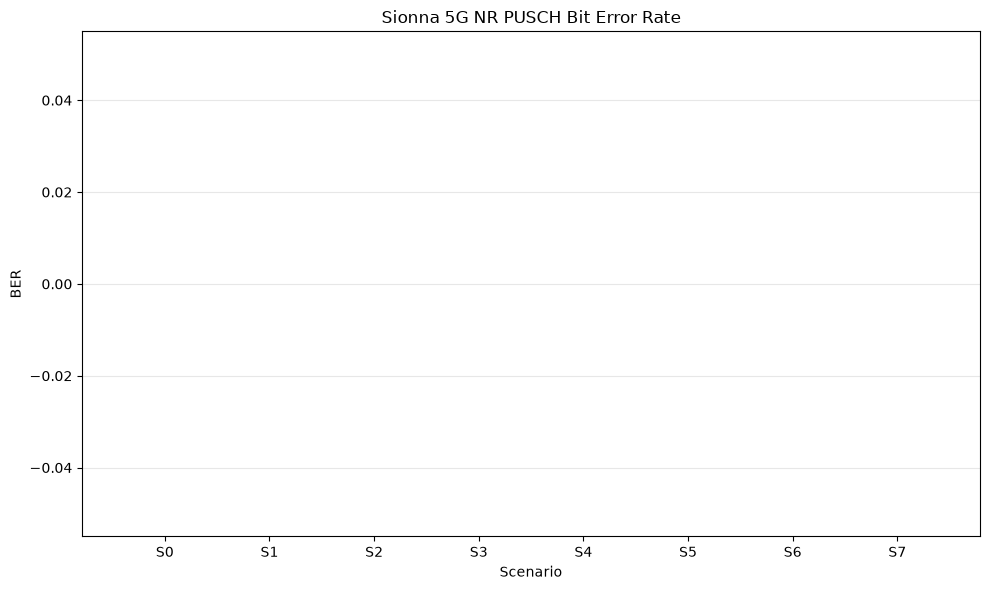

In [22]:
# ============================================================
# FIGURE 1 — SIONNA BER
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    supervisor_results["scenario"].astype(str),
    supervisor_results["BER"]
)

plt.xlabel("Scenario")
plt.ylabel("BER")
plt.title("Sionna 5G NR PUSCH Bit Error Rate")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_sionna_BER.png",
    dpi=300
)

plt.show()

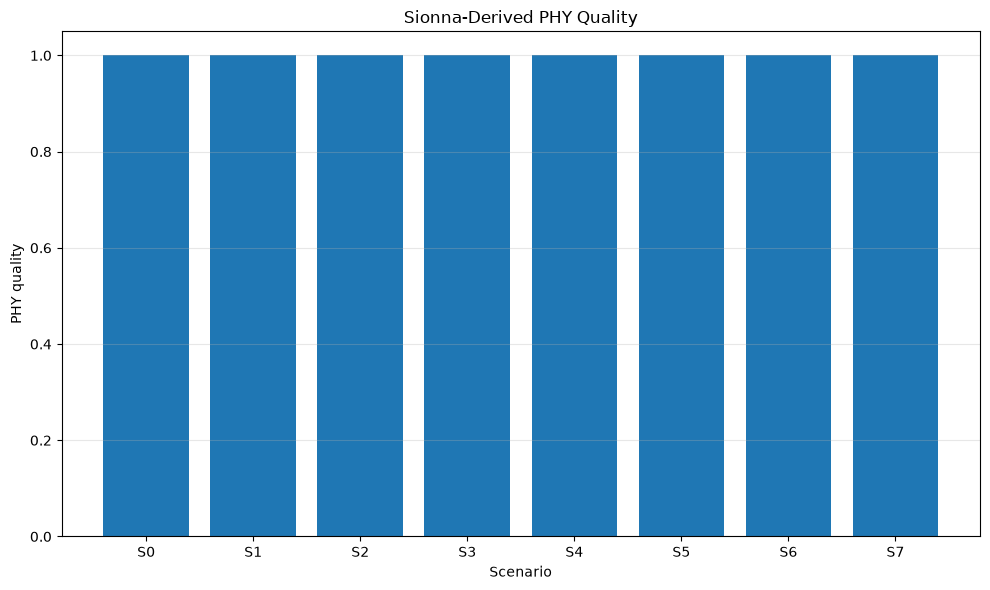

In [23]:
# ============================================================
# FIGURE 2 — SIONNA PHY QUALITY
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    supervisor_results["scenario"].astype(str),
    supervisor_results["PHY_quality"]
)

plt.xlabel("Scenario")
plt.ylabel("PHY quality")
plt.title("Sionna-Derived PHY Quality")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_sionna_PHY_quality.png",
    dpi=300
)

plt.show()

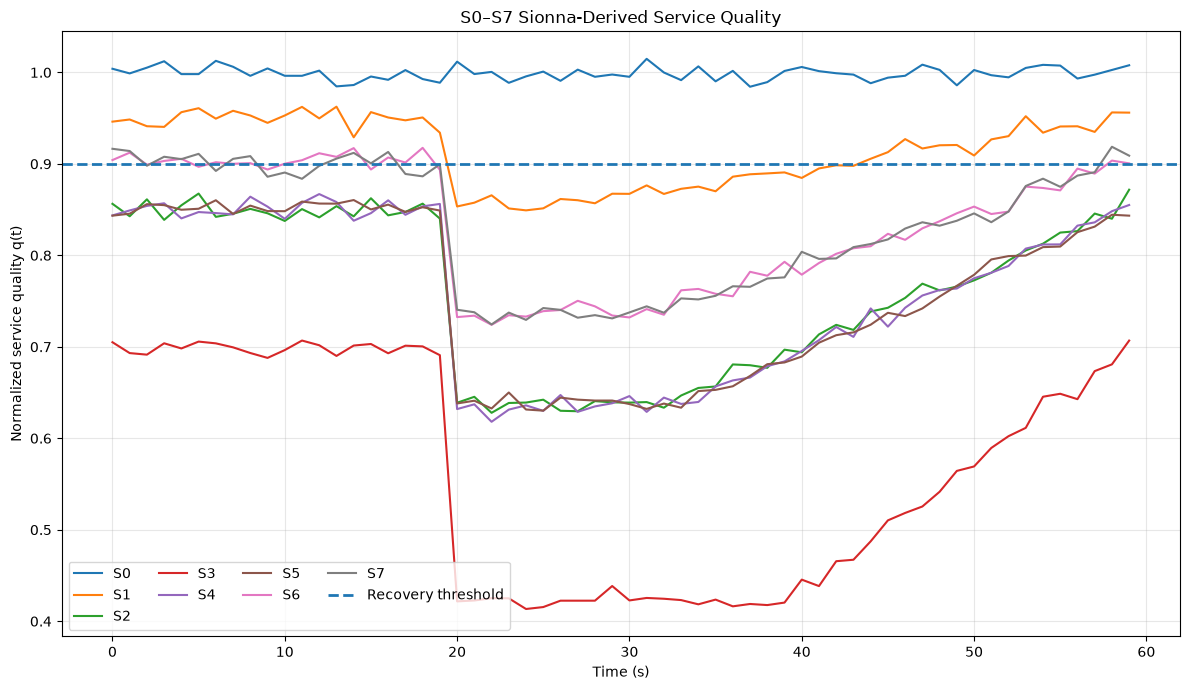

In [24]:
# ============================================================
# FIGURE 3 — Rservice QUALITY
# ============================================================

plt.figure(figsize=(12, 7))

for scenario_id in scenario_order:

    data = service_df[
        service_df["scenario"] == scenario_id
    ]

    plt.plot(
        data["time_s"],
        data["q_normalized"],
        label=scenario_id
    )

plt.axhline(
    RECOVERY_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Recovery threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized service quality q(t)")
plt.title(
    "S0–S7 Sionna-Derived Service Quality"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    ncol=4
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_service_quality.png",
    dpi=300
)

plt.show()

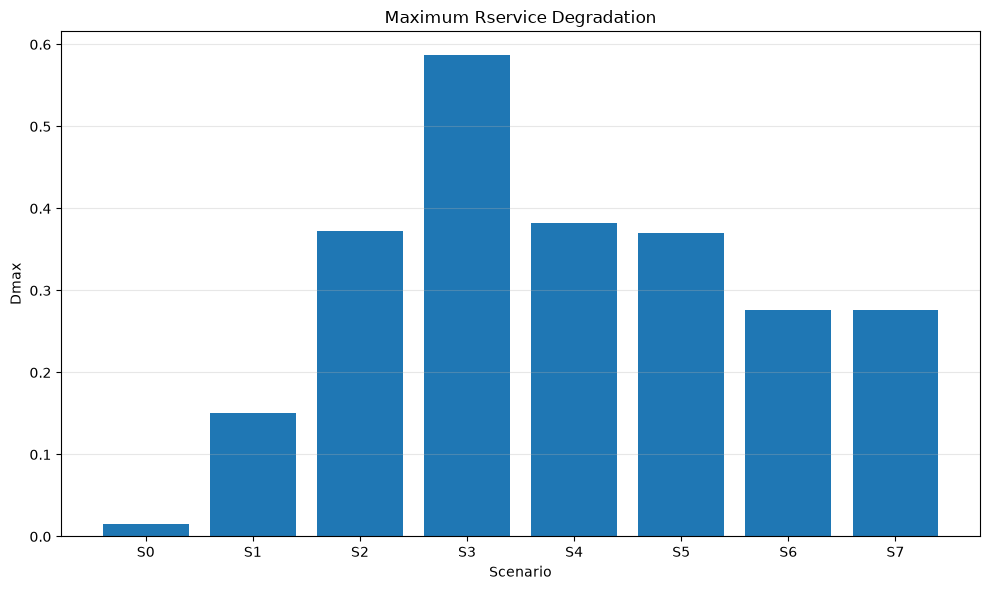

In [25]:
# ============================================================
# FIGURE 4 — Dmax
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    supervisor_results["scenario"].astype(str),
    supervisor_results["Dmax"]
)

plt.xlabel("Scenario")
plt.ylabel("Dmax")
plt.title("Maximum Rservice Degradation")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_Dmax.png",
    dpi=300
)

plt.show()

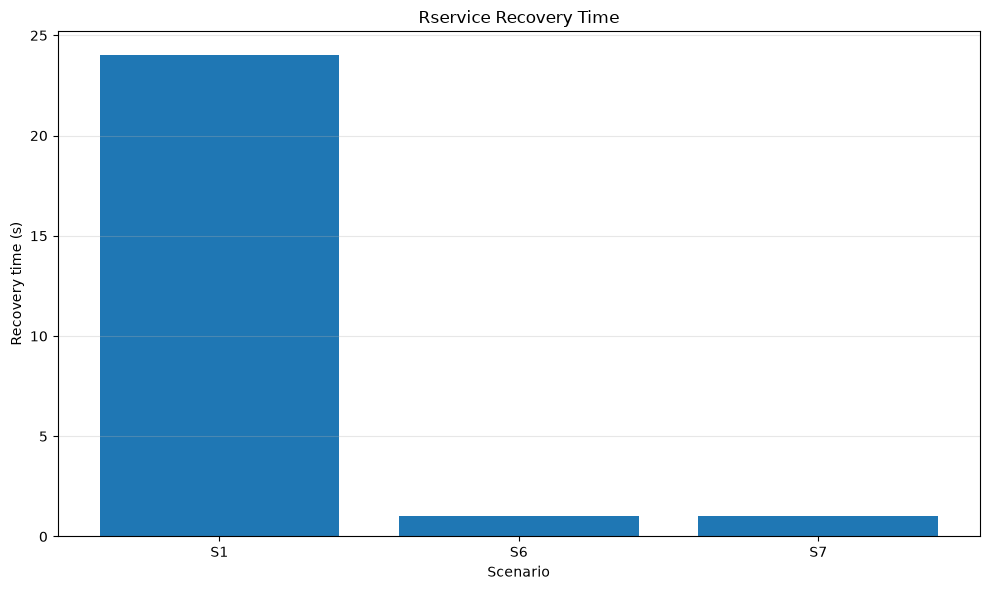

In [26]:
# ============================================================
# FIGURE 5 — RECOVERY TIME
# ============================================================

plot_data = supervisor_results.dropna(
    subset=["Trecovery_s"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["scenario"].astype(str),
    plot_data["Trecovery_s"]
)

plt.xlabel("Scenario")
plt.ylabel("Recovery time (s)")
plt.title("Rservice Recovery Time")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_recovery_time.png",
    dpi=300
)

plt.show()

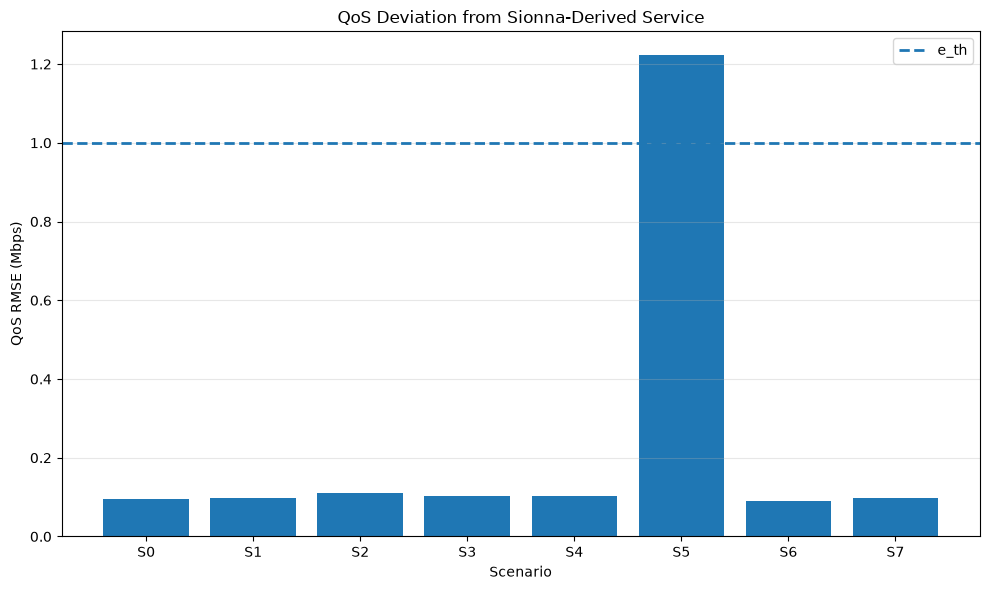

In [27]:
# ============================================================
# FIGURE 6 — QoS RMSE
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    supervisor_results["scenario"].astype(str),
    supervisor_results["QoS_RMSE_Mbps"]
)

plt.axhline(
    E_TH_MBPS,
    linestyle="--",
    linewidth=2,
    label="e_th"
)

plt.xlabel("Scenario")
plt.ylabel("QoS RMSE (Mbps)")
plt.title("QoS Deviation from Sionna-Derived Service")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_QoS_RMSE.png",
    dpi=300
)

plt.show()

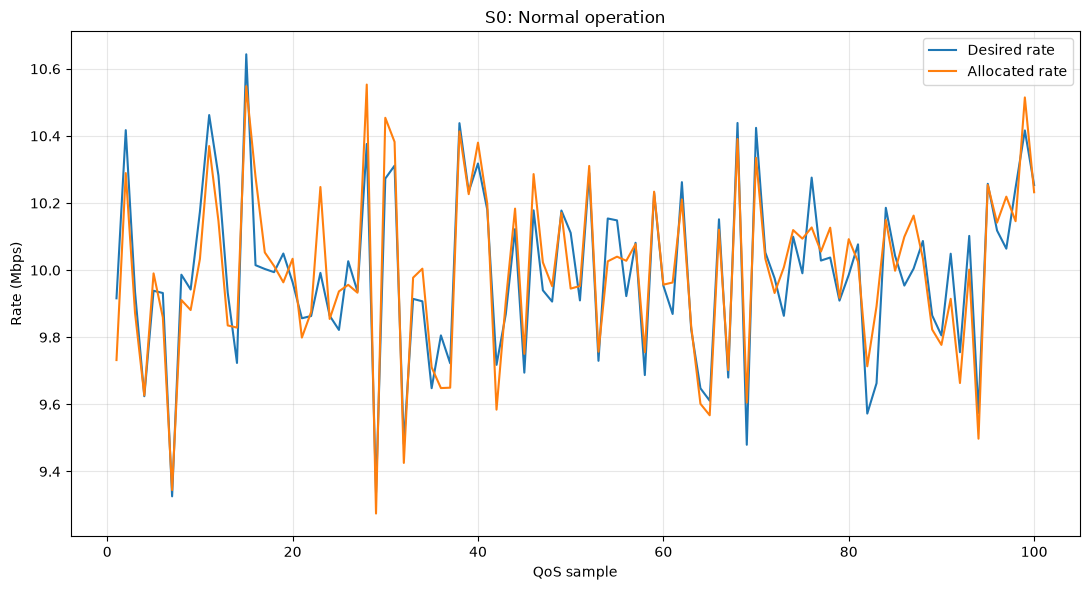

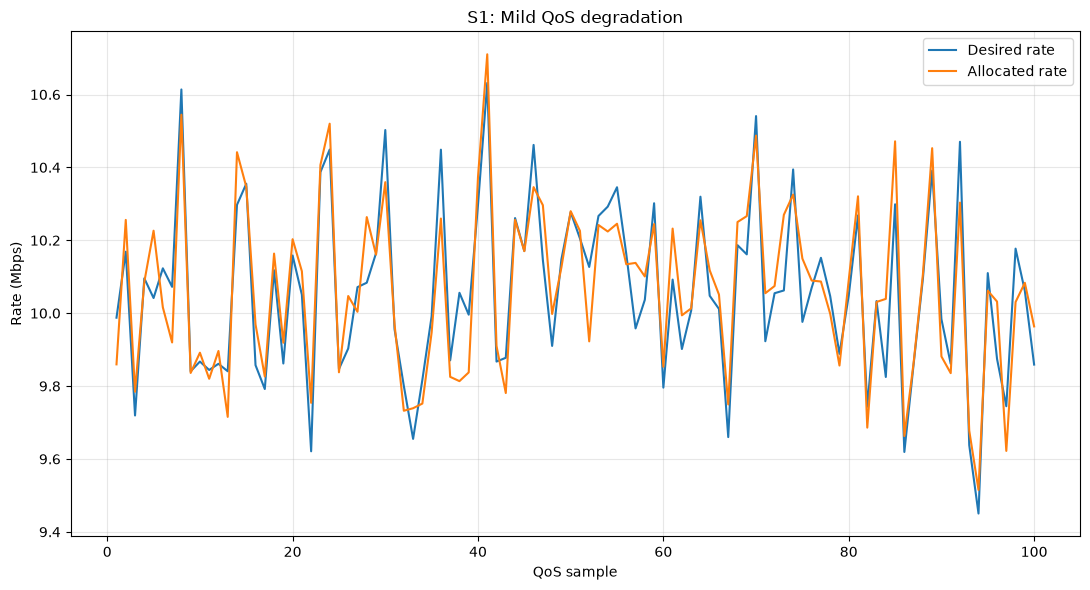

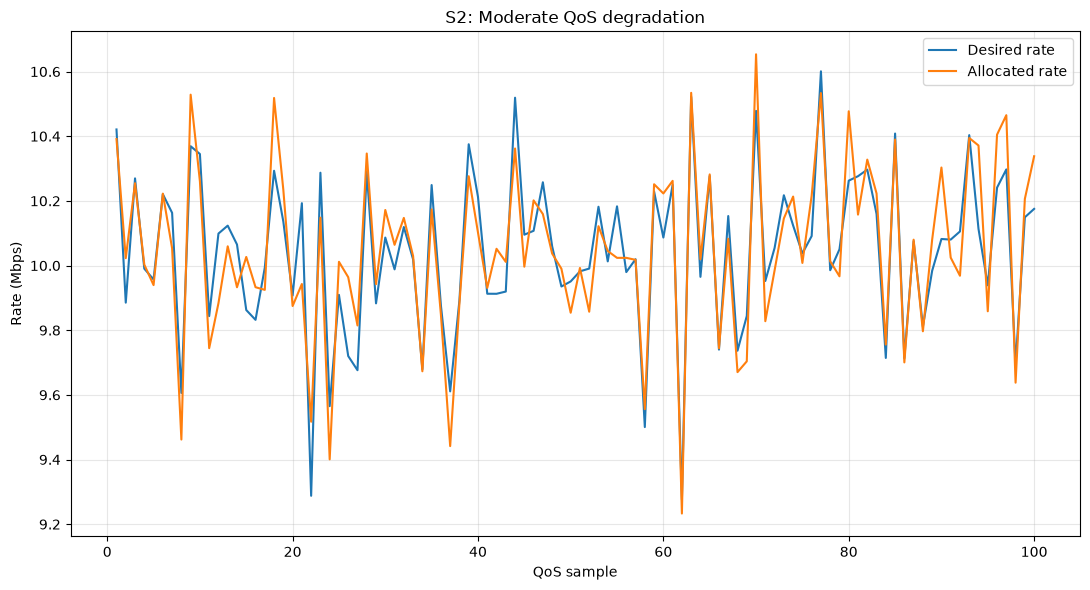

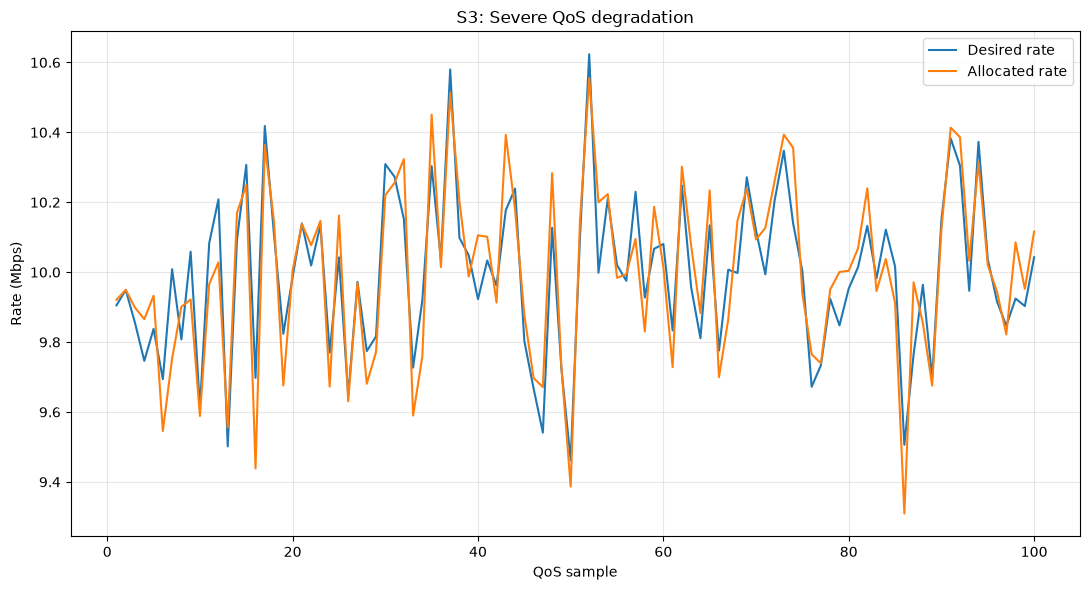

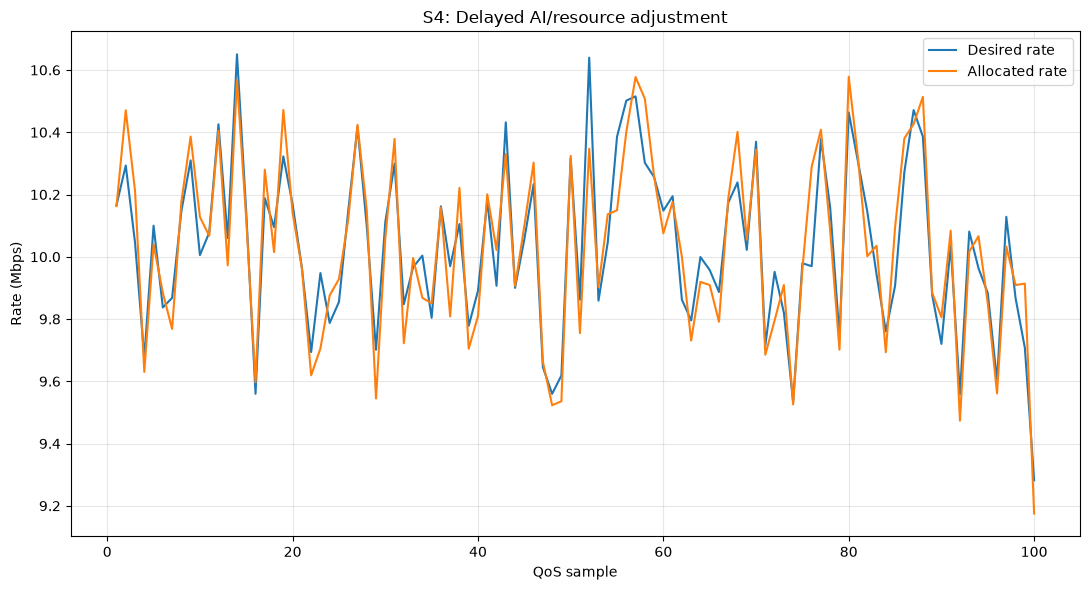

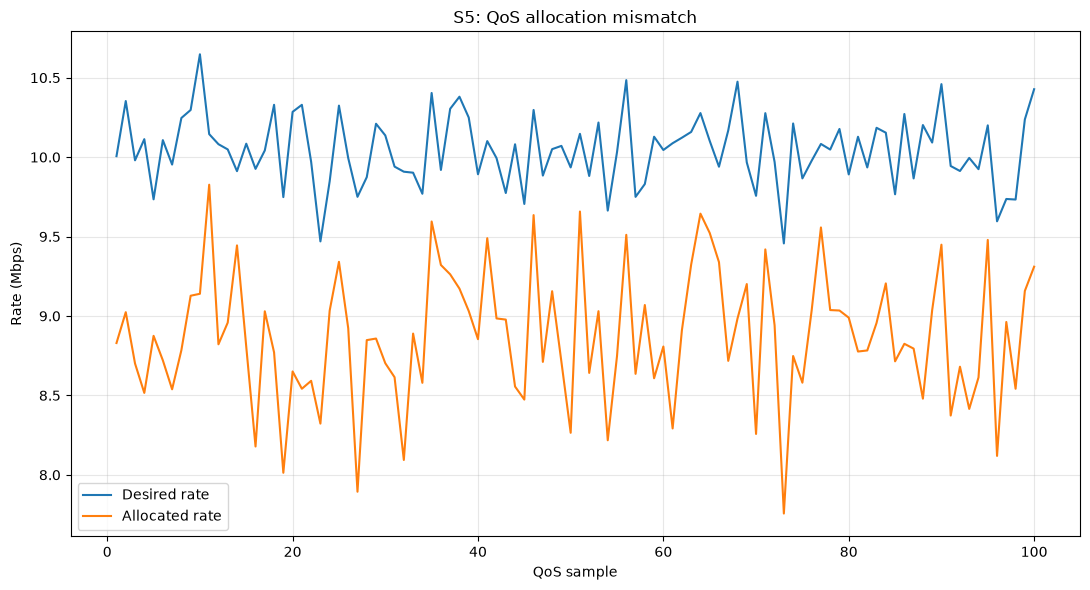

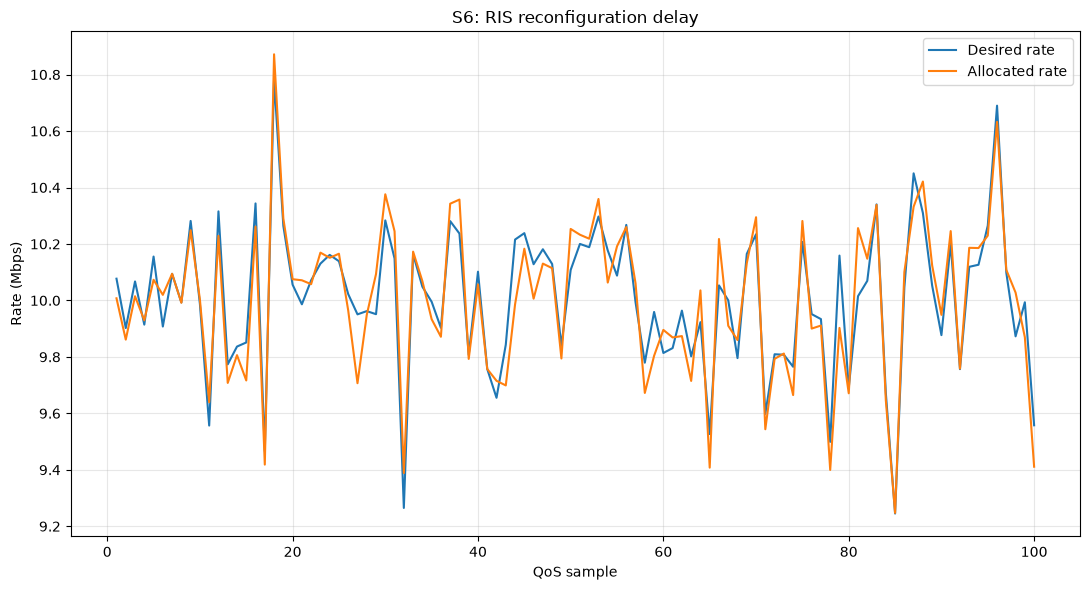

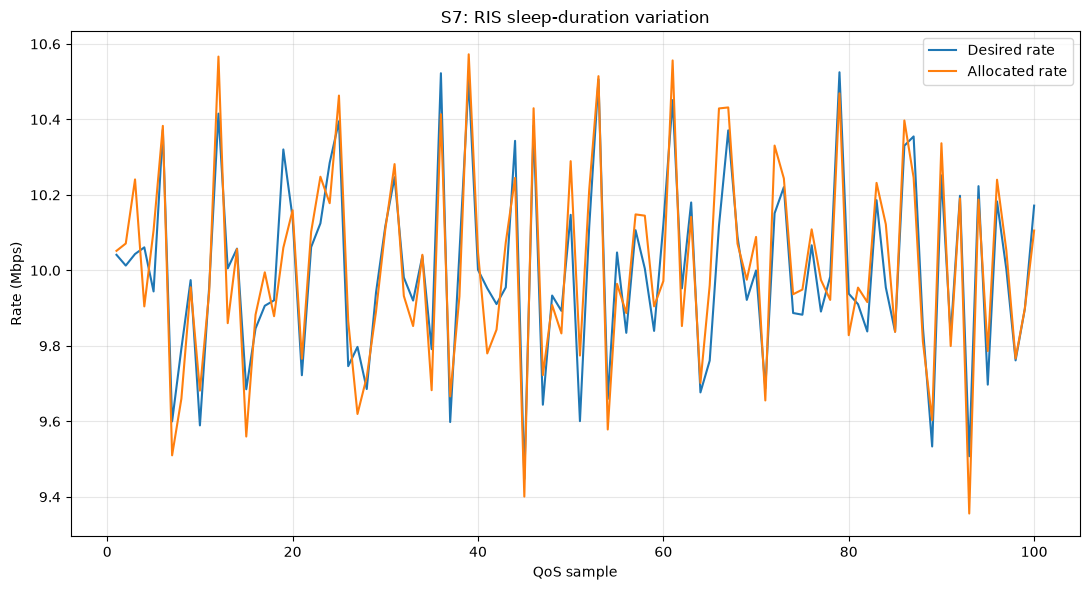

In [30]:
# ============================================================
# FIGURE 7 — DESIRED VS ALLOCATED
# ============================================================

selected = [
    "S0",
    "S1",
    "S2",
    "S3",
    "S4",
    "S5",
    "S6",
    "S7"
]

for scenario_id in selected:

    data = qos_df[
        qos_df["scenario"] == scenario_id
    ]

    plt.figure(figsize=(11, 6))

    plt.plot(
        data["sample"],
        data["desired_rate_Mbps"],
        label="Desired rate"
    )

    plt.plot(
        data["sample"],
        data["allocated_rate_Mbps"],
        label="Allocated rate"
    )

    plt.xlabel("QoS sample")
    plt.ylabel("Rate (Mbps)")

    plt.title(
        f"{scenario_id}: "
        f"{SCENARIOS[scenario_id]['description']}"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"07_QoS_{scenario_id}.png",
        dpi=300
    )

    plt.show()

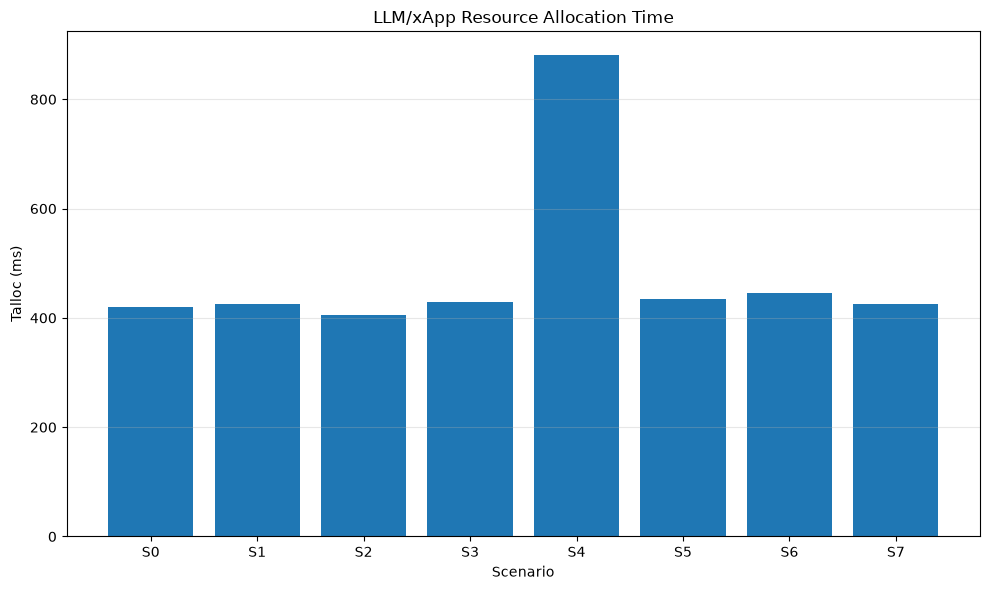

In [31]:
# ============================================================
# FIGURE 8 — LLM/xAPP ALLOCATION TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    supervisor_results["scenario"].astype(str),
    supervisor_results["Talloc_ms"]
)

plt.xlabel("Scenario")
plt.ylabel("Talloc (ms)")
plt.title("LLM/xApp Resource Allocation Time")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_Talloc.png",
    dpi=300
)

plt.show()

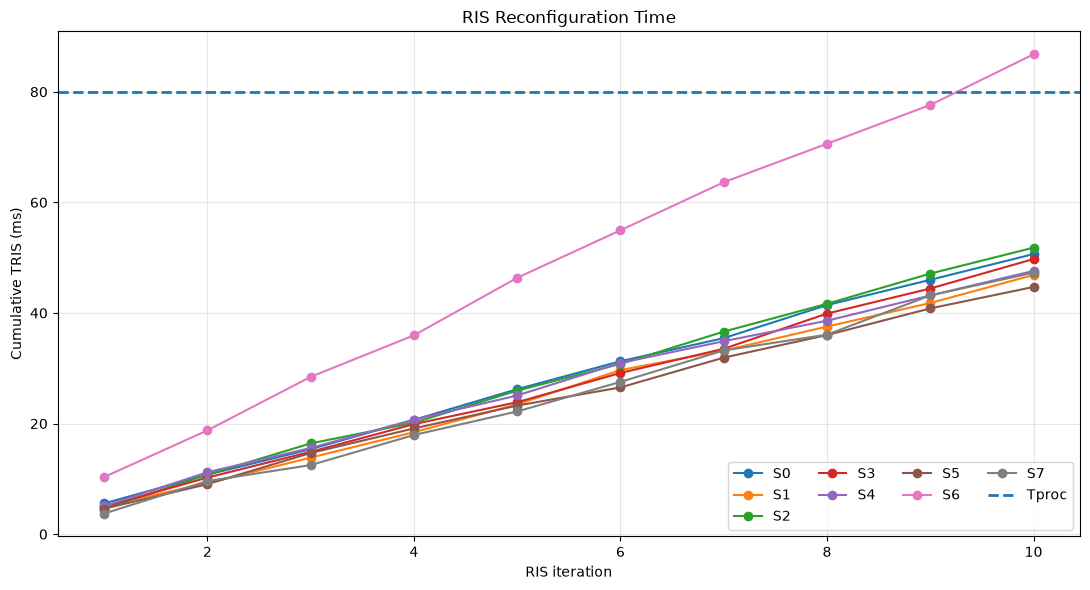

In [32]:
# ============================================================
# FIGURE 9 — RIS RECONFIGURATION
# ============================================================

plt.figure(figsize=(11, 6))

for scenario_id in scenario_order:

    data = ris_df[
        ris_df["scenario"] == scenario_id
    ]

    cumulative = data[
        "tj_RIS_ms"
    ].cumsum()

    plt.plot(
        data["ris_iteration"],
        cumulative,
        marker="o",
        label=scenario_id
    )

plt.axhline(
    T_PROC_MS,
    linestyle="--",
    linewidth=2,
    label="Tproc"
)

plt.xlabel("RIS iteration")
plt.ylabel("Cumulative TRIS (ms)")
plt.title("RIS Reconfiguration Time")

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    ncol=4
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "09_RIS_reconfiguration.png",
    dpi=300
)

plt.show()

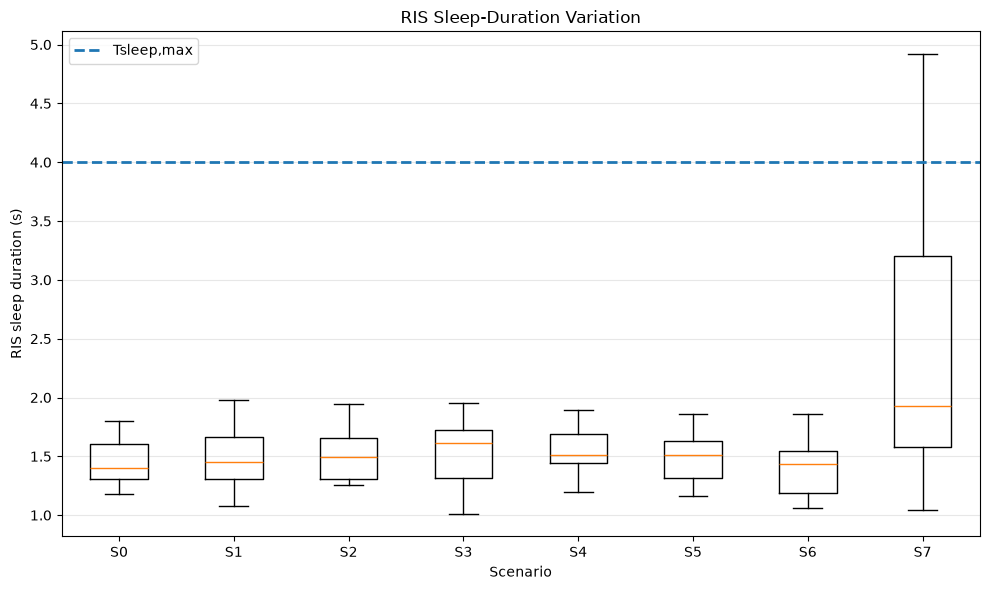

In [35]:
# ============================================================
# CELL 31 — FIGURE 10: RIS SLEEP DURATION
# ============================================================

sleep_values = []

for scenario_id in scenario_order:

    values = ris_df[
        ris_df["scenario"] == scenario_id
    ]["sleep_duration_s"].values

    sleep_values.append(values)


plt.figure(figsize=(10, 6))

plt.boxplot(
    sleep_values,
    tick_labels=scenario_order   # FIXED: labels -> tick_labels
)

plt.axhline(
    T_SLEEP_MAX_S,
    linestyle="--",
    linewidth=2,
    label="Tsleep,max"
)

plt.xlabel("Scenario")
plt.ylabel("RIS sleep duration (s)")
plt.title("RIS Sleep-Duration Variation")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "10_RIS_sleep.png",
    dpi=300
)

plt.show()

In [36]:
# ============================================================
# CELL 32 — EXPORT CSV DATA
# ============================================================

sionna_summary_df.to_csv(
    OUTPUT_DIR / "sionna_phy_results.csv",
    index=False
)

service_df.to_csv(
    OUTPUT_DIR / "service_timeseries.csv",
    index=False
)

llm_df.to_csv(
    OUTPUT_DIR / "llm_iteration_data.csv",
    index=False
)

qos_df.to_csv(
    OUTPUT_DIR / "qos_data.csv",
    index=False
)

ris_df.to_csv(
    OUTPUT_DIR / "ris_data.csv",
    index=False
)

supervisor_results.to_csv(
    OUTPUT_DIR / "supervisor_results.csv",
    index=False
)

incident_results.to_csv(
    OUTPUT_DIR / "incident_triage.csv",
    index=False
)

print("CSV files saved.")
print(OUTPUT_DIR)

CSV files saved.
/content/Rservice_S0_S7_Sionna


In [37]:
# ============================================================
# CELL 33 — EXCEL WORKBOOK
# ============================================================

excel_path = (
    OUTPUT_DIR /
    "S0_S7_Sionna_Rservice_Results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    supervisor_results.to_excel(
        writer,
        sheet_name="Rservice_Results",
        index=False
    )

    incident_results.to_excel(
        writer,
        sheet_name="Incident_Triage",
        index=False
    )

    sionna_summary_df.to_excel(
        writer,
        sheet_name="Sionna_PHY",
        index=False
    )

    service_df.to_excel(
        writer,
        sheet_name="Service_TimeSeries",
        index=False
    )

    llm_df.to_excel(
        writer,
        sheet_name="LLM_Control",
        index=False
    )

    qos_df.to_excel(
        writer,
        sheet_name="QoS",
        index=False
    )

    ris_df.to_excel(
        writer,
        sheet_name="RIS",
        index=False
    )

print("Excel workbook created:")
print(excel_path)

Excel workbook created:
/content/Rservice_S0_S7_Sionna/S0_S7_Sionna_Rservice_Results.xlsx


In [38]:
# ============================================================
# CELL 34 — FINAL SUMMARY
# ============================================================

final_columns = [
    "scenario",
    "description",
    "BER",
    "TB_success_rate",
    "PHY_quality",
    "Dmax",
    "Trecovery_s",
    "Talloc_ms",
    "Sum_di_ms",
    "QoS_RMSE_Mbps",
    "TRIS_ms",
    "Tsleep_max_s",
    "I1",
    "I2",
    "I3",
    "I4",
    "I5"
]

final_results = supervisor_results[
    final_columns
].copy()

display(final_results)

,scenario,description,BER,TB_success_rate,PHY_quality,Dmax,Trecovery_s,Talloc_ms,Sum_di_ms,QoS_RMSE_Mbps,TRIS_ms,Tsleep_max_s,I1,I2,I3,I4,I5
0,S0,Normal operation,0.0,1.0,1.0,0.0157,NaN,419.1089,134.4204,0.0952,50.6511,1.7967,0,0,0,0,0
1,S1,Mild QoS degradation,0.0,1.0,1.0,0.1508,24.0,424.8877,139.7235,0.0976,46.8731,1.9804,0,0,0,0,0
2,S2,Moderate QoS degradation,0.0,1.0,1.0,0.3721,NaN,406.1429,129.3325,0.1094,51.8151,1.9467,0,0,0,0,0
3,S3,Severe QoS degradation,0.0,1.0,1.0,0.5866,NaN,429.1052,135.0825,0.1038,49.7504,1.9515,0,0,0,0,0
4,S4,Delayed AI/resource adjustment,0.0,1.0,1.0,0.3819,NaN,880.3679,313.0271,0.1022,47.6085,1.8953,0,1,0,0,0
5,S5,QoS allocation mismatch,0.0,1.0,1.0,0.3698,NaN,435.4786,138.2844,1.2220,44.7036,1.8588,0,0,1,0,0
6,S6,RIS reconfiguration delay,0.0,1.0,1.0,0.2759,1.0,445.2929,144.9189,0.0895,86.7803,1.8588,0,0,0,1,0
7,S7,RIS sleep-duration variation,0.0,1.0,1.0,0.2756,1.0,426.2647,141.0003,0.0979,47.2954,4.9174,0,0,0,0,1


In [39]:
# ============================================================
# CELL 35 — ZIP COMPLETE EXPERIMENT
# ============================================================

import shutil

zip_file = shutil.make_archive(
    "/content/S0_S7_Sionna_Rservice",
    "zip",
    OUTPUT_DIR
)

print("================================================")
print("COMPLETE EXPERIMENT PACKAGE")
print("================================================")
print(zip_file)

COMPLETE EXPERIMENT PACKAGE
/content/S0_S7_Sionna_Rservice.zip
